In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [ ]:
DT = 2

In [3]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    df = df.sort_values(["C", "t"])
    return df



path = f'test_data_50beta_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

data['u'] = data['u'] * 1e5
data['Rx'] = data['Rx'] * 1e-8


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_55711/1156291735.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [4]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory_id'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory_id']]
    .drop_duplicates()
    .sort_values('trajectory_id')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory_id'].nunique()}")

      C  u_par  trajectory_id
0   0.7   13.2              0
1   0.8    2.2              1
2   1.1   27.0              2
3   1.3   20.1              3
4   1.4   10.0              4
5   1.8   25.8              5
6   2.0   15.5              6
7   2.3   11.2              7
8   2.3   24.2              8
9   2.6   14.6              9
10  2.8    0.6             10
11  3.2   17.7             11
12  3.3    4.7             12
13  3.6    6.7             13
14  3.7   19.2             14
15  3.9   21.4             15
16  4.2   23.5             16
17  4.3   29.7             17
18  4.7    3.3             18
19  4.9    7.8             19
Number of trajectories: 20


In [5]:
# Add a trajectory column (reuse existing IDs if already available)
if 'trajectory_id' in data.columns:
	data['trajectory'] = data['trajectory_id']
else:
	data['trajectory'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

display(data)

,u_par,C,t,V_t,I,Rx,u,ocv,trajectory_id,trajectory
10542,13.2,0.7,0,4.295441,-3.484751,-10.086727,1.897269,4.324999,0,0
10543,13.2,0.7,2,4.279840,-3.484751,-10.083731,1.897269,4.323816,0,0
10544,13.2,0.7,4,4.271748,-3.484751,-10.080733,1.897269,4.322632,0,0
10545,13.2,0.7,6,4.265244,-3.484751,-10.077735,1.897269,4.321447,0,0
10546,13.2,0.7,8,4.259728,-3.484751,-10.074737,1.897269,4.320263,0,0
...,...,...,...,...,...,...,...,...,...,...
5905,7.8,4.9,560,2.774639,-24.393256,-0.083721,1.121114,3.598965,19,19
5906,7.8,4.9,562,2.734914,-24.393256,-0.062733,1.121114,3.596569,19,19
5907,7.8,4.9,564,2.691822,-24.393256,-0.041745,1.121114,3.594173,19,19
5908,7.8,4.9,566,2.635744,-24.393256,-0.020757,1.121114,3.591777,19,19


In [6]:
# Add finite-difference columns with the same length as `data`
dV = np.diff(data['V_t'].to_numpy()) / DT
dRx = np.diff(data['Rx'].to_numpy()) / DT

if len(dV) > 0:
    dV = np.append(dV, dV[-1])
    dRx = np.append(dRx, dRx[-1])
else:
    dV = np.array([0.0])
    dRx = np.array([0.0])

data['dV_t'] = dV
data['dRx'] = dRx

data[['V_t', 'Rx', 'dV_t', 'dRx']].head()

,V_t,Rx,dV_t,dRx
10542,4.295441,-10.086727,-0.156006,0.029953
10543,4.279840,-10.083731,-0.080926,0.029983
10544,4.271748,-10.080733,-0.065036,0.029983
10545,4.265244,-10.077735,-0.055159,0.029983
10546,4.259728,-10.074737,-0.048561,0.029983


# Plotting data

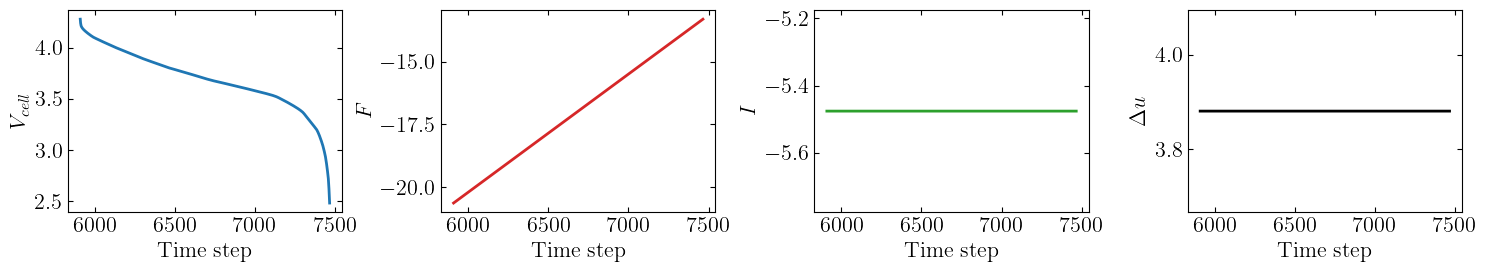

In [7]:

plot_idx = data['trajectory'] == 2
f, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0].set_xlabel('Time step')
ax[0].set_ylabel('$V_{cell}$')
ax[1].plot(data['Rx'][plot_idx], lw = 2,color = colors[1])
ax[1].set_xlabel('Time step')
ax[1].set_ylabel('$F$')
ax[2].plot(data['I'][plot_idx], lw = 2,color = colors[2])
ax[2].set_xlabel('Time step')
ax[2].set_ylabel('$I$')
ax[3].plot(data['u'][plot_idx], lw = 2,color = colors[3])
ax[3].set_xlabel('Time step')
ax[3].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

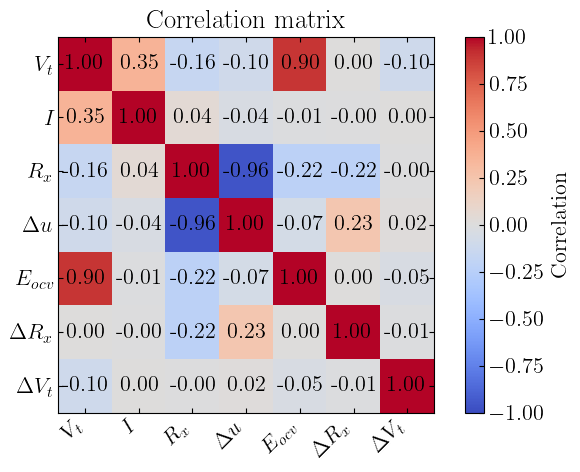

In [8]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv','dRx','dV_t']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$',r'$\Delta R_x$',r'$\Delta V_t$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

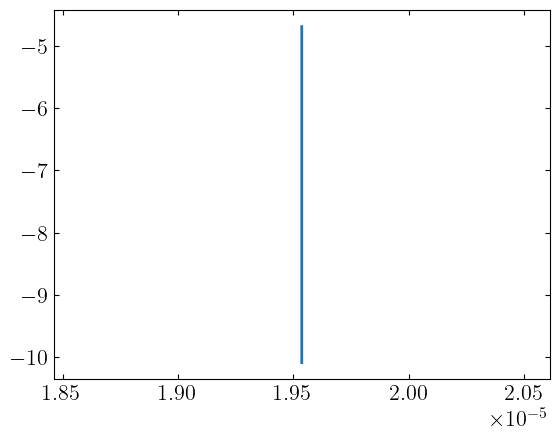

In [9]:

L_tot = 14.8e-5
traj = 0
plt.plot(data['u_par'][data['trajectory'] == traj]* L_tot / 100, data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u_par')['Rx']


first_rx = data.groupby('u_par')['Rx'].first()
k = -first_rx / (data.groupby('u_par')['u_par'].first() * L_tot / 100)


Text(0, 0.5, '$F$')

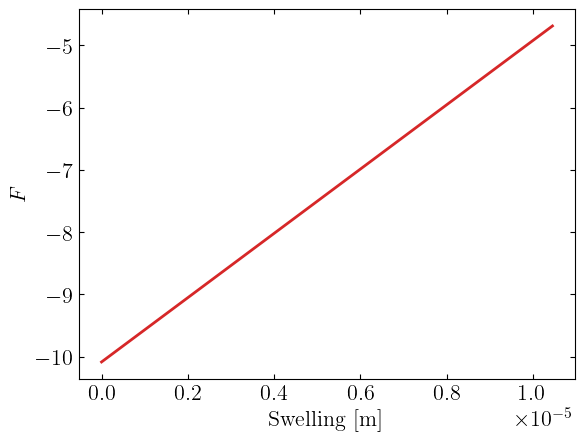

In [10]:
ds = data['Rx'][data['trajectory'] == traj] / k.values[0] + data['u_par'][data['trajectory'] == traj] * L_tot / 100

plt.plot(ds,data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel('Swelling [m]')
plt.ylabel('$F$')

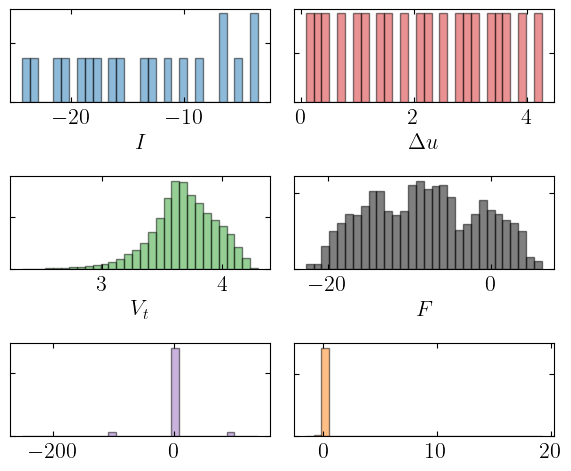

In [11]:
f, ax = plt.subplots(3,2,figsize=(6, 5))

ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['dRx']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
#ax[2,0].set_xlabel('$E_{ocv}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

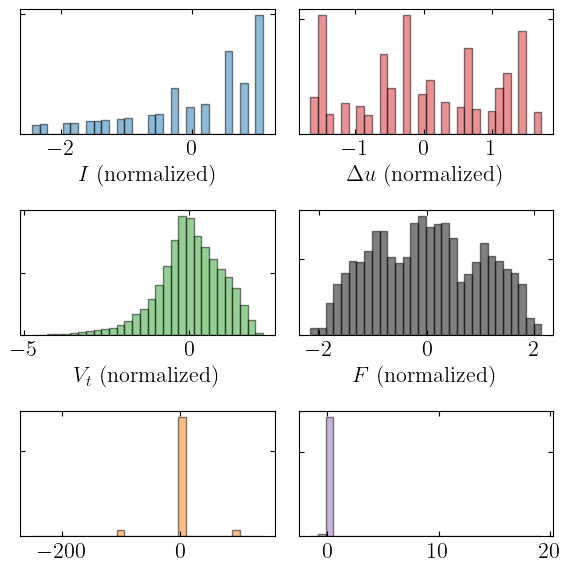

In [12]:
stats = {}

def compute_stats(x, name):
    
    if name == 'R':
        stats[name] = (np.min(x), np.max(x))
    else:
        stats[name] = (np.mean(x), np.std(x))
    return stats[name]
stats['I'] = compute_stats(data['I'], 'I')
stats['V_t'] = compute_stats(data['V_t'], 'V_t')
stats['u_par'] = compute_stats(data['u_par'], 'u_par')
stats['Rx'] = compute_stats(data['Rx'], 'Rx')
stats['dV_t'] = compute_stats(data['dV_t'], 'dV_t')
stats['dRx'] = compute_stats(data['dRx'], 'dRx')

def normalize(x, name, stats = stats):
    #if name == 'R':
    return (x - stats[name][0]) / stats[name][1]
    #else: 
    #    return (x - stats[name][0]) / (stats[name][1] - stats[name][0])

    
def denormalize(x, name, stats=stats):
    #if name == 'R':
    return x * stats[name][1] + stats[name][0]
    #else:   
    #    return x * (stats[name][1] - stats[name][0]) + stats[name][0]
    
data['I_norm'] = normalize(data['I'], 'I')
data['V_t_norm'] = normalize(data['V_t'], 'V_t')
data['u_par_norm'] = normalize(data['u_par'], 'u_par')
data['Rx_norm'] = normalize(data['Rx'], 'Rx')

f, ax = plt.subplots(3,2,figsize=(6, 6))
ax[0,0].hist(data['I_norm'], bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(data['u_par_norm'], bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)    
ax[1,0].hist(data['V_t_norm'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(data['Rx_norm'], bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(data['dRx'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$ (normalized)')
ax[0,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[1,0].set_xlabel('$V_t$ (normalized)')
ax[1,1].set_xlabel('$F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Splitting data

- The targets $y_{k+1}$ have to be extracted
    - Ensuring that the targets are within the same trajectory
    - One can check by using a `valid = (traj_id[:-1] == traj_id[1:])`
- Next, they have to matched such that each training-pair has the following form $$(y_{k+1})\sim(y_k,x_k)$$

In [13]:
N_trajs = len(data['trajectory'].unique())


test_inds = data['trajectory'] >= int(N_trajs * 0.8)

print(test_inds.sum(), 'test samples')

X = np.zeros((len(data) +1, 4))
y = np.zeros((len(data) + 1,2))
print(len(data[['V_t_norm']].values))
traj_len0 = 0

for traj_ids in range(0, N_trajs):
    traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) - 1
    X[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm','I_norm','u_par_norm']][data['trajectory'] == traj_ids].values[:-1]
    y[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm']][data['trajectory'] == traj_ids].values[1:]

    traj_len0 = traj_len1
print(X[:3])
print(y[:2])

1271 test samples
15406
[[ 2.24225289 -0.29958019  1.08870541 -0.19644497]
 [ 2.18643569 -0.2991356   1.08870541 -0.19644497]
 [ 2.15748138 -0.29869056  1.08870541 -0.19644497]]
[[ 2.18643569 -0.2991356 ]
 [ 2.15748138 -0.29869056]]


In [14]:
print(f"Number of trajectories: {N_trajs}")

Number of trajectories: 20


In [15]:

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

train_loader_flat = DataLoader(TensorDataset(x_train, y_train), batch_size=256 , shuffle=False)

Number of trajectories in train: 16 out of 20
X shape torch.Size([15407, 4])	y shape torch.Size([15407, 2])
X-train shape: torch.Size([14482, 4])	y-train shape: torch.Size([14482, 2])
X-test shape: torch.Size([925, 4])	y-test shape: torch.Size([925, 2])


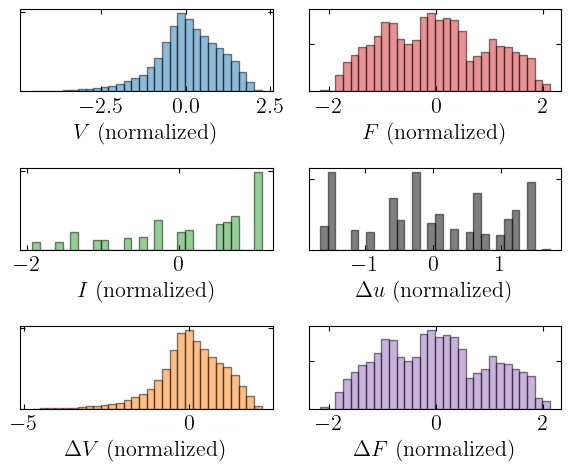

In [16]:
# plotting histograms of the training data
f, ax = plt.subplots(3,2,figsize=(6, 5))
ax[0,0].hist(x_train[:,0].numpy(), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(x_train[:,1].numpy(), bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)    
ax[1,0].hist(x_train[:,2].numpy(), bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(x_train[:,3].numpy(), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(y_train[:,0].numpy(), bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(y_train[:,1].numpy(), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$V  $ (normalized)')
ax[0,1].set_xlabel('$F$ (normalized)')
ax[1,0].set_xlabel('$I$ (normalized)')
ax[1,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[2,0].set_xlabel(r'$\Delta V$ (normalized)')
ax[2,1].set_xlabel(r'$\Delta F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()



# Defining model

Inputs: $I_t$, $\Delta u_t$, $V_t$, $F_t$

Outputs $\dot{V}_t$, $\dot{F}_t$

Employing a NODE setup, with the state variable $\xi = [V,F]$, we get $$\dot{\xi}=f_{NN}(I_t,\Delta u_t,\xi)\Rightarrow \xi(t) = \int_0^tf_{NN}(I_t,\Delta u_t,\xi)\,\mathrm{d}t$$

In [17]:
''' Mk 1 '''
import torch.nn.functional as FUNC


class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )
    
    # def forward(self, x,yk):
    #     X = torch.cat((x,yk), dim=1)
    #     yk1 = self.net(X)
    #     return yk1
    def forward(self, input, PE = False):
        if PE:
            
            
            V_dot_raw = self.net(input)[:,0:1]
            F_dot_raw = self.net(input)[:,1:2]
            
            #V_dot_raw_unnorm = denormalize(V_dot_raw, 'dV_t')
            #F_dot_raw_unnorm = denormalize(F_dot_raw, 'dRx')

            F_dot_unnorm =  FUNC.relu(F_dot_raw)
            V_dot_unnorm = -FUNC.relu(V_dot_raw)             

            V_dot = normalize(V_dot_unnorm, 'V_t')
            F_dot = normalize(F_dot_unnorm, 'Rx')
            return torch.cat((V_dot, F_dot), dim=1)
        else:
            out = self.net(input)

            # V_dot = denormalize(out[:, 0:1], 'V_t')
            # F_dot = denormalize(out[:, 1:2], 'Rx')

            # if (V_dot > 0).any():
            #     print('V_dot > 0 warning')

            # if (F_dot < 0).any():
            #     print('F_dot < 0 warning')

            return out
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [18]:
try: 
    print(summary(model, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [2, 2]                    --
├─Sequential: 1-1                        [2, 2]                    --
│    └─Linear: 2-1                       [2, 256]                  1,280
│    └─ReLU: 2-2                         [2, 256]                  --
│    └─Linear: 2-3                       [2, 256]                  65,792
│    └─ReLU: 2-4                         [2, 256]                  --
│    └─Linear: 2-5                       [2, 2]                    514
Total params: 67,586
Trainable params: 67,586
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.14
Input size (MB): 0.25
Forward/backward pass size (MB): 0.01
Params size (MB): 0.27
Estimated Total Size (MB): 0.53


# Training
Since we only have values for $V_t$ and $F_t$, we need to add a torch-compatible integrator within the training procedure. For starters, we use the simple Euler forward, yielding the following loss $$\mathcal{L} = \|\xi_t-f_{NN}(x_t)\Delta t\|^2_2\quad x_t = [I_t,\Delta u_t].$$
After training, the model could in principle be used in your favorite integrator. 

In [19]:
def next_step(dy, X, dt=DT, stats=stats):
    y = X[:, :2]

    V = denormalize(y[:,0], 'V_t', stats)
    F = denormalize(y[:,1], 'Rx', stats)

    dV = denormalize(dy[:,0], 'dV_t', stats)
    dF = denormalize(dy[:,1], 'dRx', stats)

    V1 = V + dV * dt
    F1 = F + dF * dt

    y1 = torch.zeros_like(y)
    y1[:,0] = normalize(V1, 'V_t', stats)
    y1[:,1] = normalize(F1, 'Rx', stats)

    return y1



In [20]:
def next_step_rk4(model, X, dt=DT, stats=stats):
    y = X[:, :2]          # state
    extra = X[:, 2:]      # other features (must be preserved)

    def to_phys(y):
        V = denormalize(y[:, 0], 'V_t', stats)
        F = denormalize(y[:, 1], 'Rx', stats)
        return torch.stack([V, F], dim=1)

    def to_norm(Y):
        y_norm = torch.zeros_like(Y)
        y_norm[:, 0] = normalize(Y[:, 0], 'V_t', stats)
        y_norm[:, 1] = normalize(Y[:, 1], 'Rx', stats)
        return y_norm

    def f(Y_phys):
        Y_norm = to_norm(Y_phys)

        X_full = torch.cat([Y_norm, extra], dim=1)

        dy = model(X_full)

        dV = denormalize(dy[:, 0], 'dV_t', stats)
        dF = denormalize(dy[:, 1], 'dRx', stats)
        return torch.stack([dV, dF], dim=1)

    Y0 = to_phys(y)

    k1 = f(Y0)
    k2 = f(Y0 + 0.5 * dt * k1)
    k3 = f(Y0 + 0.5 * dt * k2)
    k4 = f(Y0 + dt * k3)

    Y1 = Y0 + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    y_next = to_norm(Y1)

    return torch.cat([y_next, extra], dim=1)

def step(model, x, dt):
    return next_step_rk4(model, x, dt)

def next_step_stable(model, x, dt, substeps=5):
    dt_small = dt / substeps
    for _ in range(substeps):
        x = step(model, x, dt_small)
    return x
    

def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    tot_time = 0.0
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        start_t = time.perf_counter()
        for x_b, y_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            y_pred = next_step_stable(model, x_b, DT, substeps=5)[:,:2]

            d_loss = nn.MSELoss()(y_pred, y_b)
            tot_loss = d_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item()
            d_ep_loss += d_loss.item()
        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["time per ep"].append(end_t - start_t)
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | time {end_t - start_t:.2f}s")

    return history

In [21]:
history = training(epochs=100)

ETA: 2.32 min
Epoch 1 | loss 1.966e-03 | time 1.39s
Epoch 2 | loss 6.065e-04 | time 1.43s
Epoch 3 | loss 4.842e-04 | time 1.39s
Epoch 4 | loss 1.121e-04 | time 1.31s
Epoch 5 | loss 1.162e-04 | time 1.43s
Epoch 6 | loss 8.335e-05 | time 1.37s
Epoch 7 | loss 5.068e-05 | time 1.41s
Epoch 8 | loss 5.147e-05 | time 1.33s
Epoch 9 | loss 4.553e-05 | time 1.50s
Epoch 10 | loss 4.381e-05 | time 1.31s
Epoch 11 | loss 3.348e-05 | time 1.31s
Epoch 12 | loss 3.064e-05 | time 1.30s
Epoch 13 | loss 2.894e-05 | time 1.42s
Epoch 14 | loss 2.730e-05 | time 1.38s
Epoch 15 | loss 2.912e-05 | time 1.81s
Epoch 16 | loss 2.172e-05 | time 1.31s
Epoch 17 | loss 2.008e-05 | time 1.39s
Epoch 18 | loss 2.014e-05 | time 1.35s
Epoch 19 | loss 2.110e-05 | time 1.30s
Epoch 20 | loss 1.431e-05 | time 1.31s
Epoch 21 | loss 1.548e-05 | time 1.30s
Epoch 22 | loss 1.344e-05 | time 1.50s
Epoch 23 | loss 1.158e-05 | time 1.55s
Epoch 24 | loss 1.214e-05 | time 1.50s
Epoch 25 | loss 1.544e-05 | time 1.75s
Epoch 26 | loss 8.96

6.701132835155925e-06


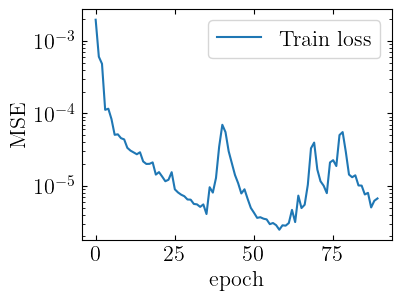

In [22]:
#model_name = 'Second_PENN_ReLU'
#PENN_exp_log.exp_log(model, history, current = currents,name=model_name, d_loss_type = 'mse')
#torch.save(model.state_dict(), f'models/{model_name}_{currents}.pth')
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

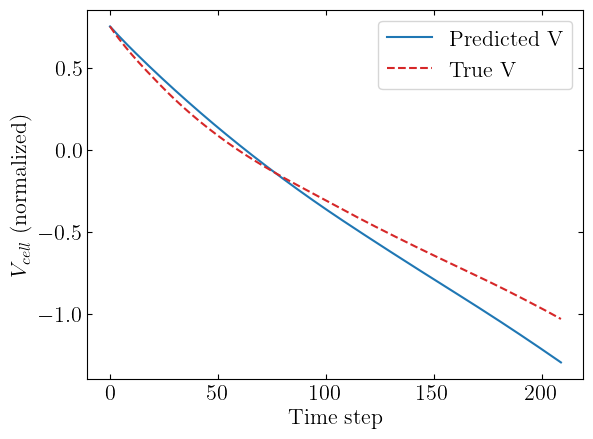

In [26]:
from scipy.interpolate import interp1d

def denorm_y(y, stats=stats):
    V = denormalize(y[:,0], 'V_t', stats)
    F = denormalize(y[:,1], 'Rx', stats)
    return np.stack([V, F], axis=1)

def rollout(model, x_init, steps=100):
    dt = DT
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    x = x_init.clone()
    traj[0] = x[0, :2].numpy()
    model.eval()
    for t in range(1,steps):
        with torch.no_grad():

            x = next_step_rk4(model, x, dt, stats)
            traj[t] = x[0, :2].numpy()
            dy = model(x)[:,:2]
            traj_dy[t] = dy[0].numpy()
    return traj,traj_dy

rollout_steps = 210

traj,traj_dy = rollout(model, x_test[:1], steps=rollout_steps)

plt.plot(traj[:,0], label='Predicted V', color=colors[0])
plt.plot(x_test[:rollout_steps,0].numpy(), label='True V', color=colors[1],ls = '--')
plt.xlabel('Time step')
plt.ylabel('$V_{cell}$ (normalized)')
plt.legend()


[ 0.7553891 -2.1245954]


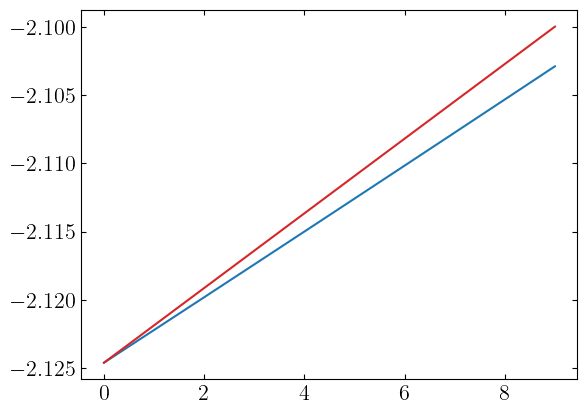

In [24]:
def rollout(model,x_init,steps=100):
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    x = x_init.clone()
    y0 = x[:2].numpy()
    print(y0)
    traj[0] = y0
    model.eval()
    for t in range(1,steps):
        with torch.no_grad():
            dy = model(x)
            V1 = denormalize(x[0], 'V_t', stats) + denormalize(dy[0],'dV_t') * DT
            F1 = denormalize(x[1], 'Rx', stats) + denormalize(dy[1],'dRx') * DT
            x[0] = normalize(V1, 'V_t', stats)
            x[1] = normalize(F1, 'Rx', stats)

            traj[t] = x[:2].numpy()
            traj_dy[t] = dy.numpy()
    return traj,traj_dy

traj,traj_dy = rollout(model, x_test[:1][0], steps=10)
plt.plot(traj[:,1], label='Predicted dV', color=colors[0])
plt.plot(x_test[:10,1].numpy(), label='True dV', color=colors[1])

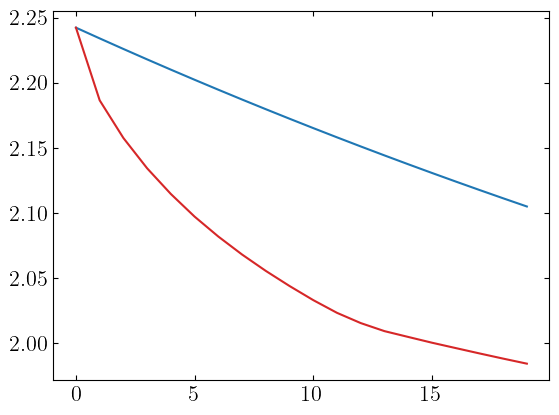

In [25]:
def rollout_backward(model, x_init, steps=100, max_iter=10, dt = DT, stats=stats):
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    
    x = x_init.clone()
    traj[0] = x[:2].numpy()

    model.eval()

    for t in range(1, steps):
        x_old = x.clone()
        x_new = x.clone()  # initial guess

        for _ in range(max_iter):
            with torch.no_grad():
                dy = model(x_new)

                V1 = denormalize(x_old[0], 'V_t', stats) + denormalize(dy[0], 'dV_t') * dt
                F1 = denormalize(x_old[1], 'Rx', stats) + denormalize(dy[1], 'dRx') * dt

                x_new[0] = normalize(V1, 'V_t', stats)
                x_new[1] = normalize(F1, 'Rx', stats)

        x = x_new.clone()

        traj[t] = x[:2].numpy()
        traj_dy[t] = dy.numpy()

    return traj, traj_dy


steps = 20
traj, traj_dy = rollout_backward(model, x_train[:1][0], steps=steps, max_iter=30)
plt.plot(traj[:,0], label='Predicted V', color=colors[0])
plt.plot(x_train[:steps,0].numpy(), label='True V', color=colors[1])